# Flight Price Prediction using Machine Learning

## Import Libraries

In [1]:
import pandas as pd  #for data manipulation
import numpy as np   #for numerical calculations
import matplotlib.pyplot as plt   #for plotting graphs
import seaborn as sns   #for advanced visualizations

In [2]:
#ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [3]:
data = pd.read_excel("data/Flight_Fare.xlsx")

In [4]:
#first 5 rows of the dataset
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
#number of rows and columns
data.shape

(10683, 11)

In [6]:
#name of the columns in dataset
data.columns  

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [7]:
#getting some informations about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
#shows statistical information
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Exploratory Data Analysis (EDA)

In [9]:
#checking for missing values
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [10]:
#remove missing values because ML models cannot handle missing values
data.dropna(inplace=True)

In [11]:
#check duplicates
data.duplicated().sum()

np.int64(220)

In [12]:
#remove duplicates
data.drop_duplicates(inplace=True)

## Data Visualization

### Price Distribution

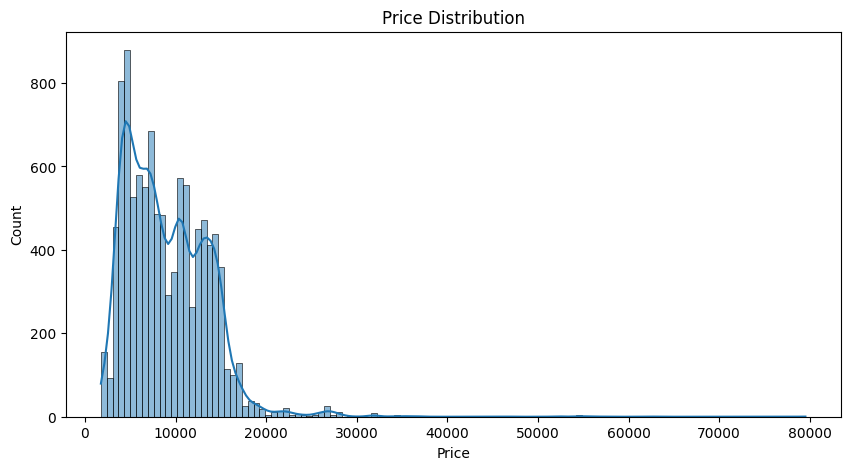

In [13]:
#shows skewness by price
plt.figure(figsize=(10,5))
sns.histplot(data['Price'],kde=True)
plt.title("Price Distribution")
plt.show()

### Airline vs Price

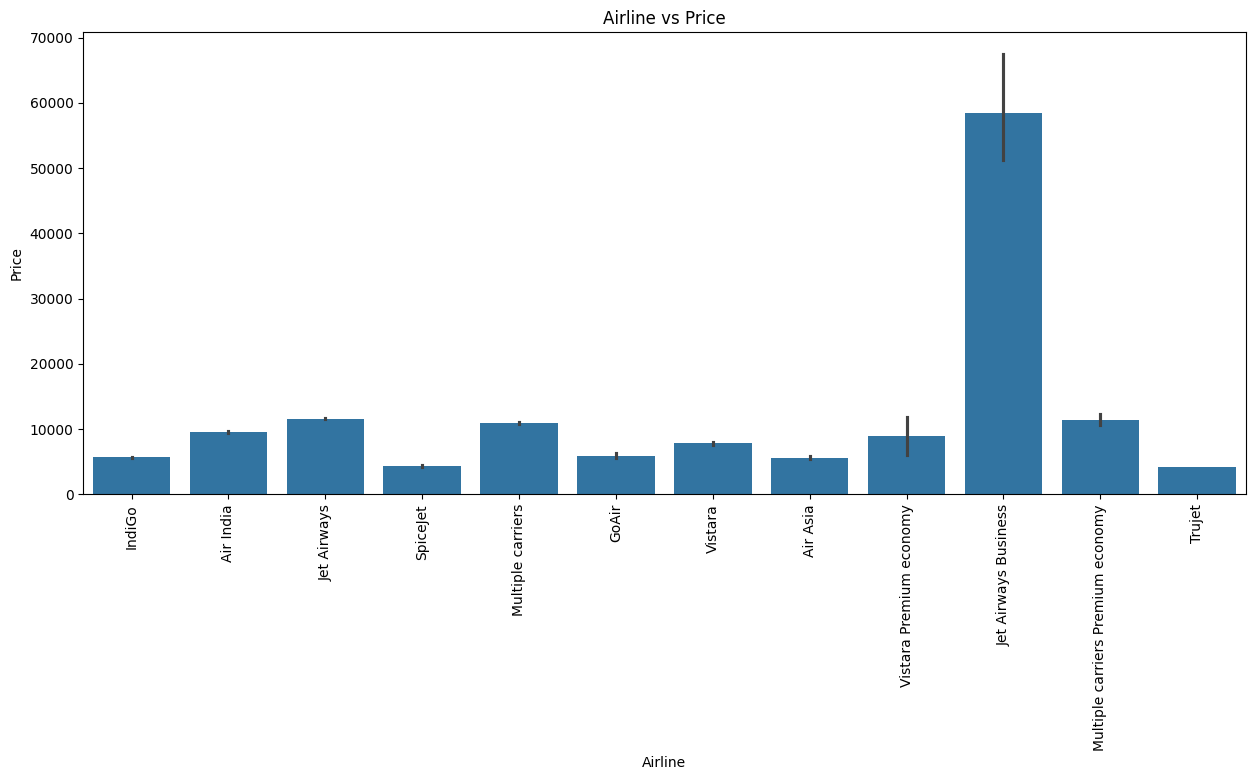

In [14]:
#compares average ticket prices
plt.figure(figsize=(15,6))
sns.barplot(x="Airline",y='Price',data=data)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

### Source vs Price

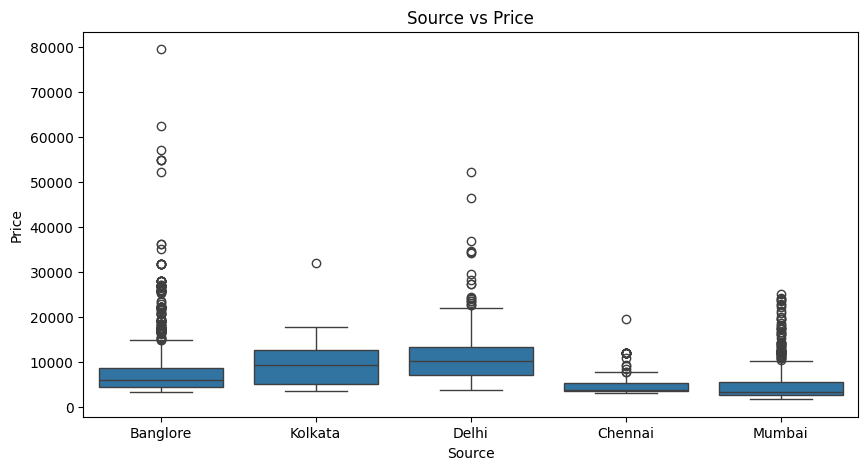

In [15]:
#shows how ticket prices are different by city
plt.figure(figsize=(10,5))
sns.boxplot(x='Source',y='Price',data=data)
plt.title("Source vs Price")
plt.show()

### Destination vs Price

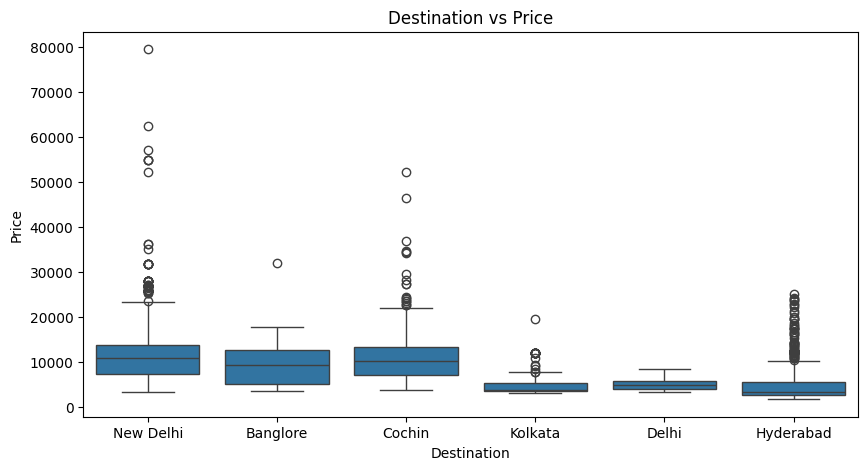

In [16]:
#shows which destination routes are costly
plt.figure(figsize=(10,5))
sns.boxplot(x='Destination',y='Price',data=data)
plt.title("Destination vs Price")
plt.show()

### Total_Stops vs Price

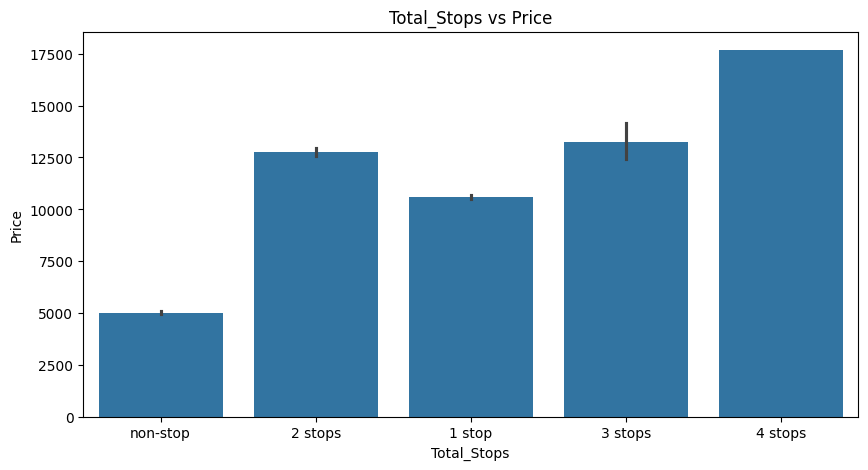

In [17]:
#shows impact of stopovers on ticket prices that is more stops=high duration=high price
plt.figure(figsize=(10,5))
sns.barplot(x='Total_Stops',y='Price',data=data)
plt.title("Total_Stops vs Price")
plt.show()

### Duration vs Price

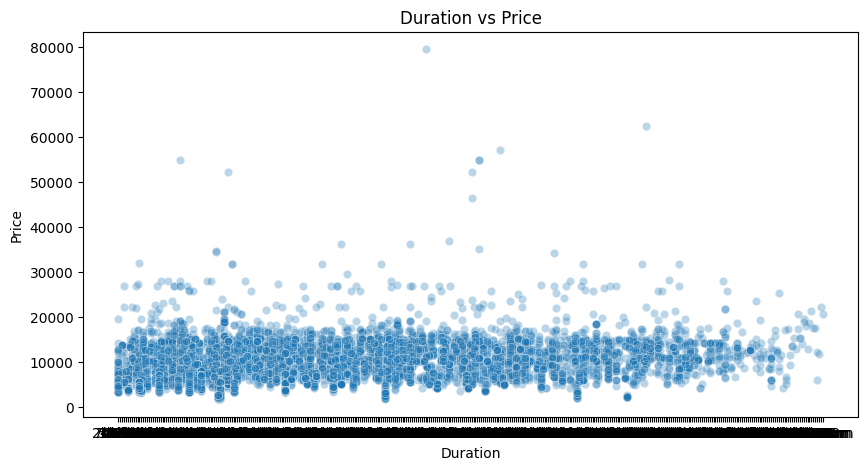

In [18]:
#checks whether longer flights cost more
plt.figure(figsize=(10,5))
sns.scatterplot(x="Duration", y="Price", data=data, alpha=0.3)
plt.title("Duration vs Price")
plt.show()

## Outlier Detection
Checks unusual high or low prices

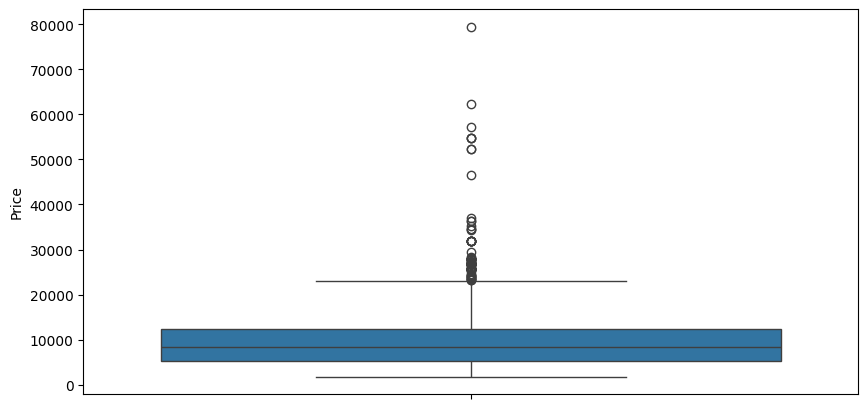

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data["Price"])
plt.show()

## Outlier Handling using IQR Method

In [20]:
Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data["Price"] >= lower) & (data["Price"] <= upper)]

## Feature Engineering

In [21]:
# Convert Date Column
data["Journey_day"] = pd.to_datetime(data.Date_of_Journey,format="%d/%m/%Y").dt.day   #day of travel affects ticket prices
data["Journey_month"] = pd.to_datetime(data["Date_of_Journey"],format="%d/%m/%Y").dt.month  #seasonality affects prices

In [22]:
data.drop(["Date_of_Journey"],axis=1,inplace=True)  #model cannot directly understand date

In [23]:
# Extract Departure Time
data["Dep_hour"] = pd.to_datetime(data["Dep_Time"]).dt.hour  #morning and evening flights have different pricing
data["Dep_min"] = pd.to_datetime(data["Dep_Time"]).dt.minute  #gives more precise timing

In [24]:
data.drop(["Dep_Time"],axis=1,inplace=True)   #text is not useful for models

In [25]:
# Extract Arrival Time
data["Arrival_hour"] = pd.to_datetime(data["Arrival_Time"]).dt.hour   #arrival timing can affect pricing
data["Arrival_min"] = pd.to_datetime(data["Arrival_Time"]).dt.minute

In [26]:
data.drop(["Arrival_Time"],axis=1,inplace=True)

In [27]:
# Convert Duration
duration = list(data["Duration"])    #ML cannot understand categorical data

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

duration_hours = []
duration_mins = []

for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep="h")[0]))

    duration_mins.append(int(duration[i].split(sep="m")[0].split()[-1]))

data["Duration_hours"] = duration_hours
data["Duration_mins"] = duration_mins

In [28]:
data.drop(["Duration"], axis=1, inplace=True)    #numerical data are easier for ML models

In [29]:
# Convert Total stops because Models require numeric data
data['Total_Stops'] = data["Total_Stops"].map({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

## Categorical Encoding
Converts categorical data into binary columns (OneHot Encoding)

In [30]:
from sklearn.preprocessing import OneHotEncoder
data=pd.get_dummies(data,drop_first=True)

## Correlation Heatmap
Shows highly correlated values.

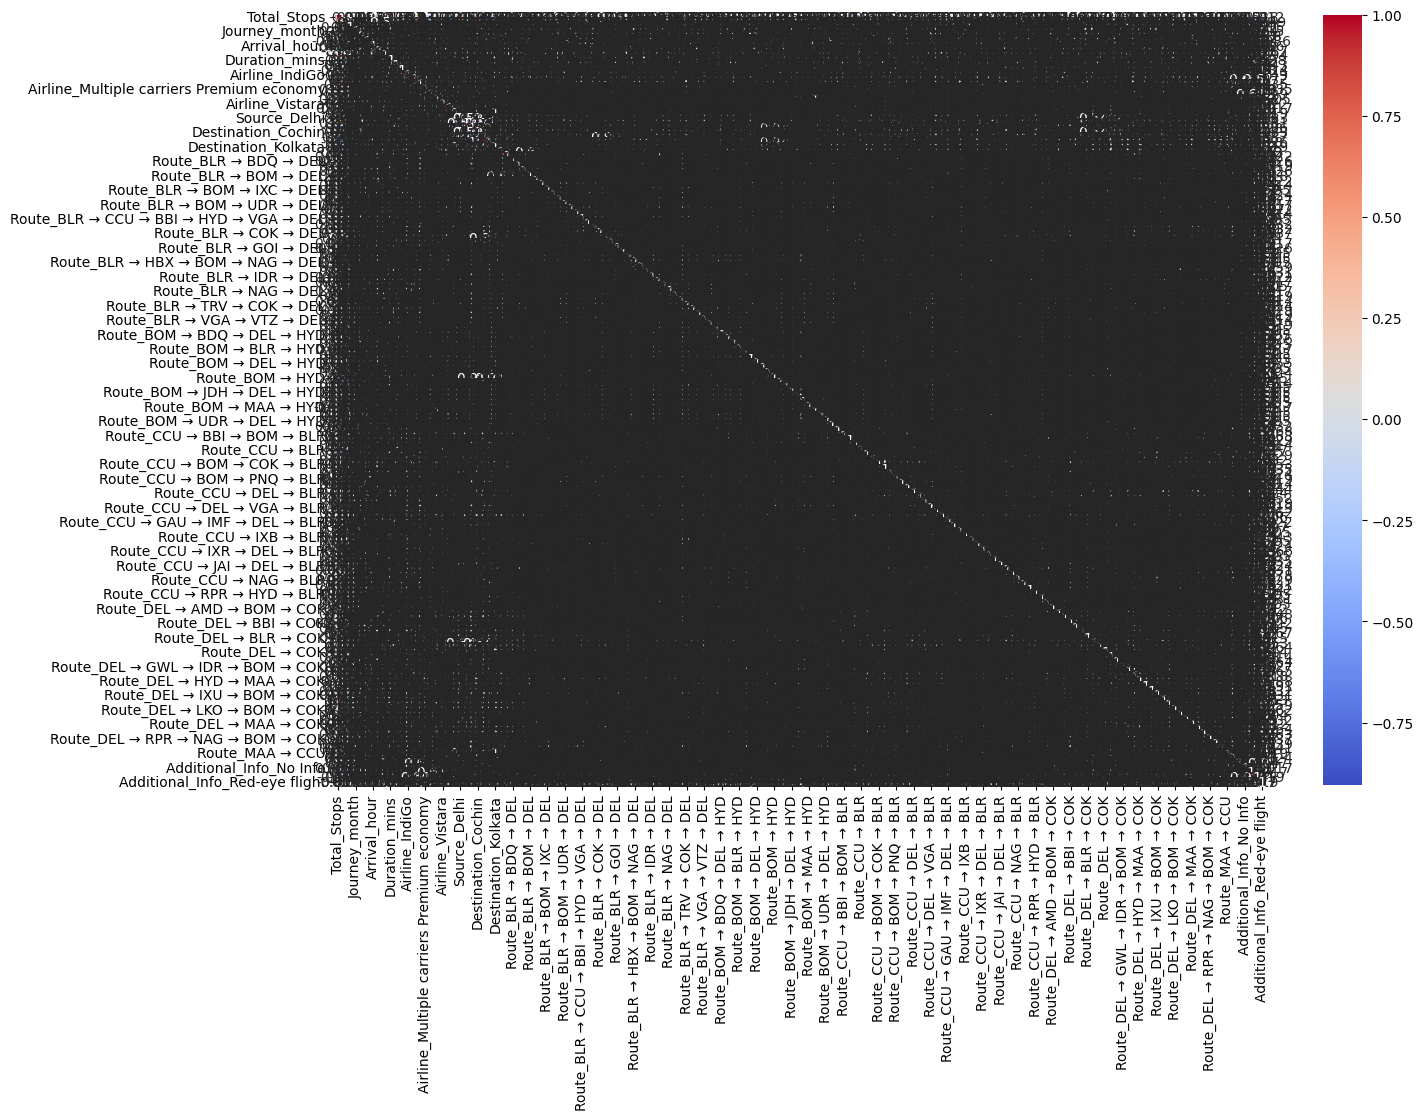

In [31]:
plt.figure(figsize=(15,10))    
sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

## Model Building

In [32]:
# Define x and y (feature (input) and target variable (output))
x = data.drop("Price",axis=1)
y = data["Price"]

In [33]:
# Train test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)  #80%=Traning and 20%=Testing

## Model Training

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Linear Regression

In [35]:
lr = LinearRegression()    #base model, fast training and easy to interpret
lr.fit(x_train, y_train)   #understand how well a simple linear relationship could predict flight prices

LinearRegression()

In [36]:
y_pred_lr = lr.predict(x_test)

### Decision Tree

In [37]:
dt = DecisionTreeRegressor(random_state=42)   #detect non-linear patterns and no scaling required
dt.fit(x_train, y_train)       #checks non-linear relationships that cannot be captured by linear regression

DecisionTreeRegressor()

In [38]:
y_pred_dt = dt.predict(x_test)

### Random Forest

In [39]:
rf = RandomForestRegressor(random_state=42)  #combines many trees, High accuracy and Less overfitting
rf.fit(x_train, y_train)

RandomForestRegressor()

In [40]:
y_pred_rf = rf.predict(x_test)

## Evaluate Models

In [41]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [42]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)  #average prediction error. lower is better
    mse = mean_squared_error(y_test, y_pred)   #penalizes large errors heavily. lower is better
    rmse = np.sqrt(mse)                        #error in original units. lower is better
    r2 = r2_score(y_test, y_pred)              #measures variance shown by models. higher is better
    
    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE :",rmse)
    print("R2 Score :",r2)

In [43]:
# Linear Regression
evaluate(y_test, y_pred_lr)

MAE : 1428.1623864966946
MSE : 3903892.4543298827
RMSE : 1975.8270304684777
R2 Score : 0.759501943839056


In [44]:
# Decision Tree
evaluate(y_test, y_pred_dt)

MAE : 650.0457248473159
MSE : 2071738.6166961319
RMSE : 1439.3535412455592
R2 Score : 0.8723711997659247


In [45]:
# Random Forest
evaluate(y_test, y_pred_rf)

MAE : 589.212983633344
MSE : 1284359.2500524786
RMSE : 1133.2957469489058
R2 Score : 0.9208774558563063


## Compare Models
Compares r2 scores of all models and helps to choose the best model.

In [46]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', ' Random Forest'],
    'R2 Score':[
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})
models

,Model,R2 Score
0,Linear Regression,0.759502
1,Decision Tree,0.872371
2,Random Forest,0.920877


## Hyperparameter Tuning
Finds best random forest settings automatically.

In [47]:
from sklearn.model_selection import GridSearchCV
param_grid_rf = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,30],

    "min_samples_split":[2,5,10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(x_train,y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9243304168102673


In [48]:
best_rf = grid_rf.best_estimator_

## Cross Validation
Checks the model on multiple train-test splits.

In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    x,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average CV Score:", scores.mean())

[0.93069081 0.93136195 0.93523798 0.92002897 0.9306133 ]
Average CV Score: 0.9295866041244857


## Feature Importance
Shows which features influence ticket prices most.

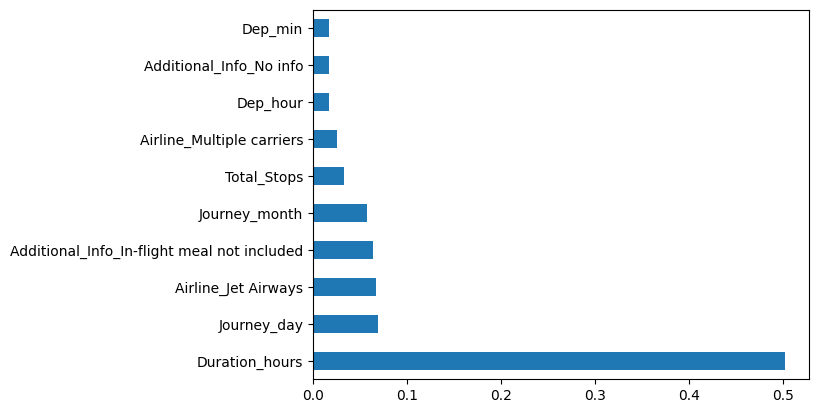

In [50]:
importance = pd.Series(best_rf.feature_importances_, index=x.columns)
importance.nlargest(10).plot(kind='barh')
plt.show()

## Save Model
Stores trained model.

In [51]:
import pickle   
pickle.dump(best_rf, open("flight_price_model.pkl","wb"))

## Model Comparison Report

# Final Conclusion

# Challenges Faced